## Ejercicio: Recorrido de una red de distribución

# Laboratorio de Grafos - BFS y DFS

# Andrés Matías Carballo
# Juan Felipe Herrera
# Laura Juliana Cerón


## Diagrama de flujo


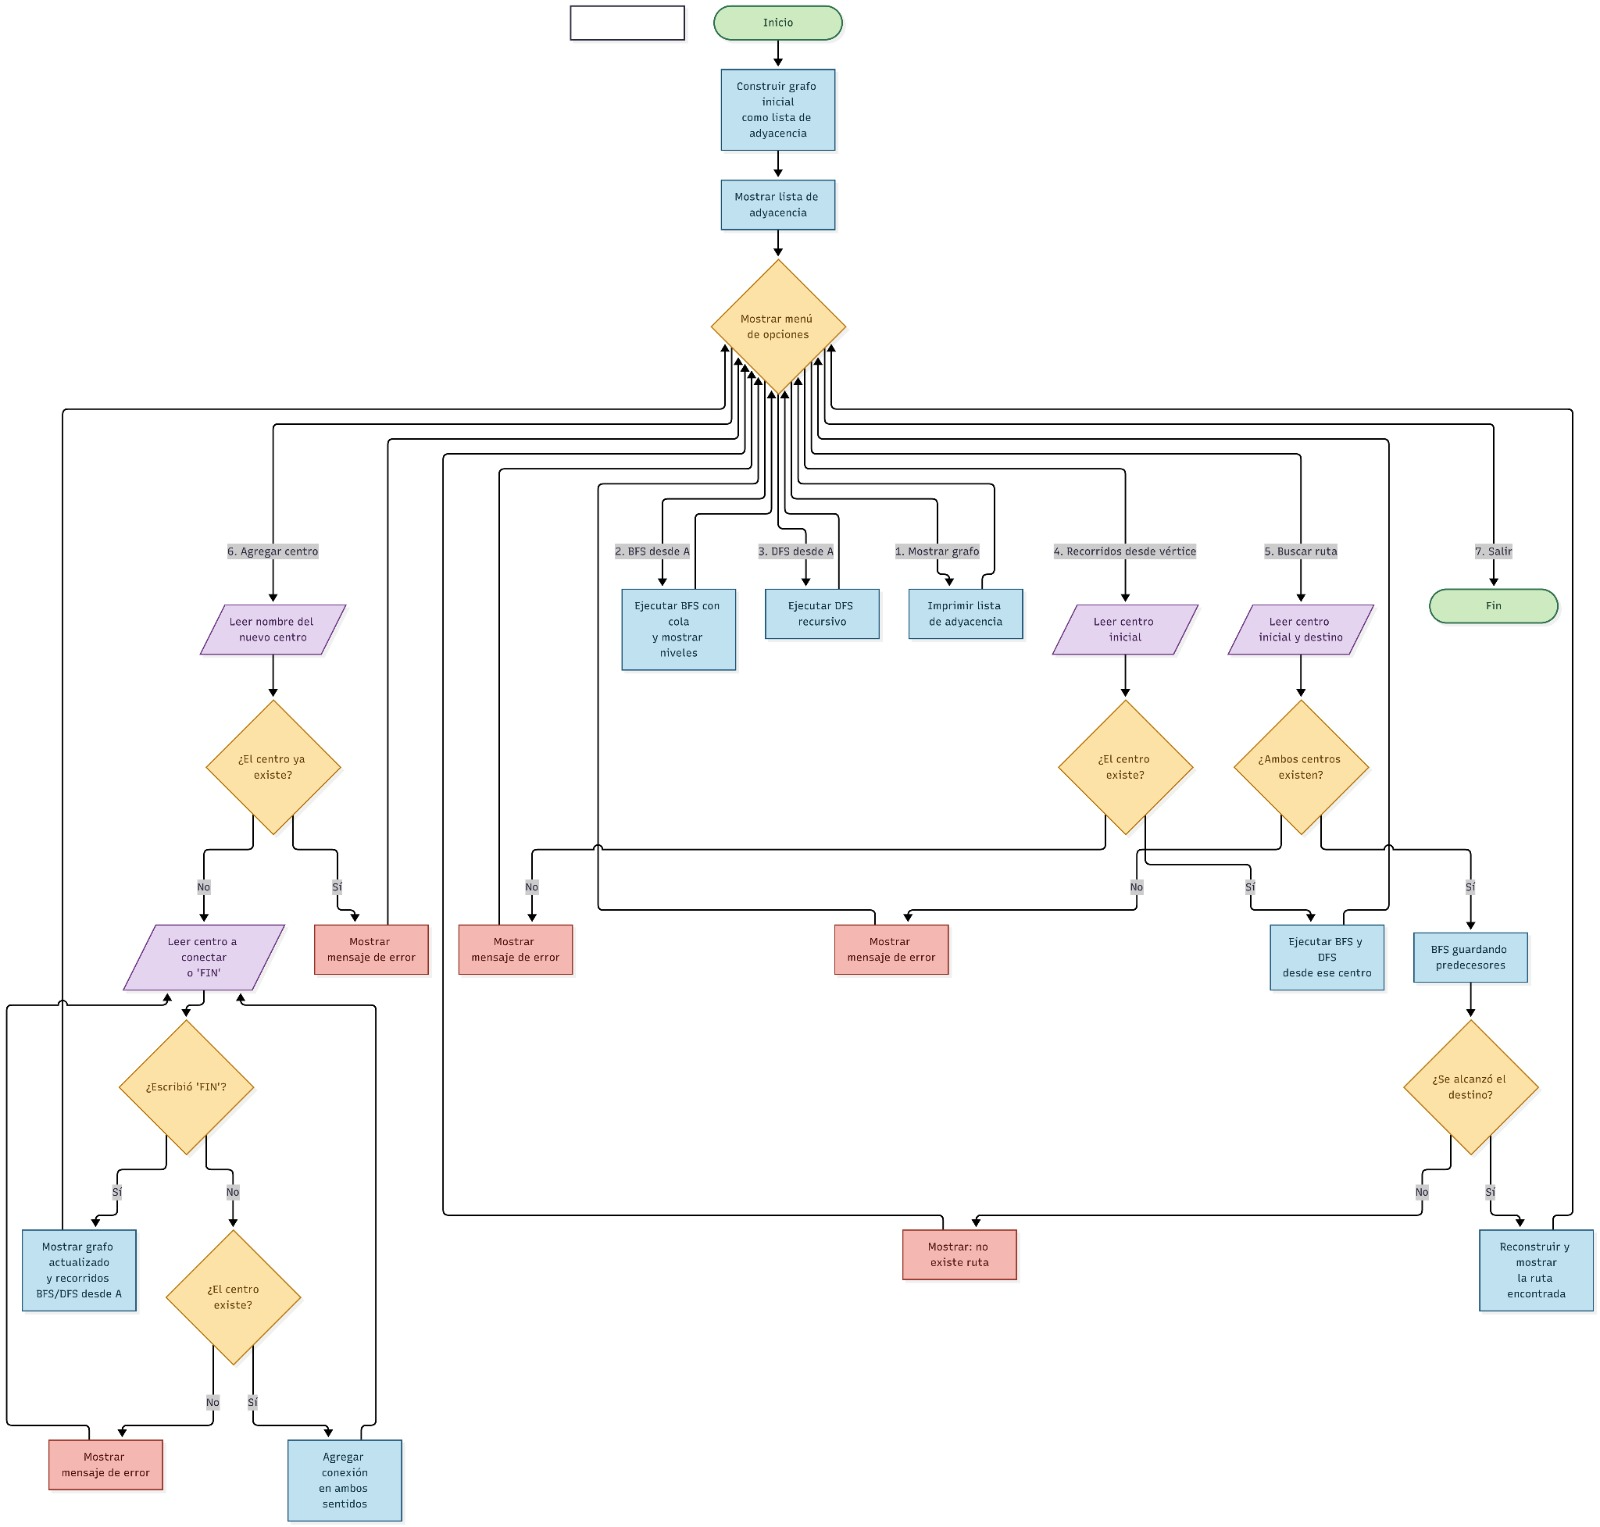

# Descripción diagrama de flujo

El programa arranca construyendo el grafo inicial como lista de adyacencia y mostrándolo. A partir de ahí entra en un bucle principal controlado por un menú de 7 opciones que se repite hasta que el usuario elige salir. Las opciones 1, 2 y 3 son directas (mostrar el grafo, BFS desde A, DFS desde A). La opción 4 valida primero que el centro ingresado exista antes de ejecutar los recorridos, repreguntando si no existe. La opción 5 aplica un BFS que además guarda el predecesor de cada nodo, para poder reconstruir la ruta completa si el destino es alcanzado, o informar que no existe ruta si no lo es; también valida cada centro por separado antes de continuar. La opción 6 tiene su propio bucle interno para leer conexiones una a una hasta que el usuario escribe 'FIN', validando en cada paso que el centro a conectar exista, y agregando cada conexión en ambos sentidos por tratarse de un grafo no dirigido; al terminar, actualiza y vuelve a mostrar el grafo y sus recorridos. En cualquier caso, el flujo siempre retorna al menú hasta que se selecciona la opción de salir.


## Código funcional


In [ ]:
import sys
sys.setrecursionlimit(5000)


def pedir_texto_no_vacio(mensaje):
    while True:
        try:
            texto = input(mensaje).strip().upper()
            if texto != "":
                return texto
            print("El campo no puede estar vacío.")
        except (EOFError, KeyboardInterrupt):
            print("Entrada no disponible.")
            return None


def pedir_opcion(mensaje, opciones_validas):
    while True:
        try:
            texto = input(mensaje).strip()
            if texto == "":
                print("La entrada no puede estar vacía.")
                continue
            if texto in opciones_validas:
                return texto
            print(f"Opción inválida. Elija una de: {', '.join(opciones_validas)}")
        except (EOFError, KeyboardInterrupt):
            print("Entrada no disponible.")
            return None


def construir_grafo_inicial():
    return {
        "A": ["B", "C"],
        "B": ["A", "D", "E"],
        "C": ["A", "F"],
        "D": ["B"],
        "E": ["B", "G"],
        "F": ["C", "G"],
        "G": ["E", "F"],
    }


def mostrar_grafo(grafo):
    print("\n--- Lista de adyacencia ---")
    for centro, vecinos in grafo.items():
        print(f"{centro}: {vecinos}")


def vertice_existe(grafo, vertice):
    return vertice in grafo


def bfs(grafo, inicio):
    if not vertice_existe(grafo, inicio):
        return None, None
    visitados = {inicio}
    niveles = {inicio: 0}
    cola = [inicio]
    orden = []
    while cola:
        actual = cola.pop(0)
        orden.append(actual)
        for vecino in grafo.get(actual, []):
            if vecino not in visitados:
                visitados.add(vecino)
                niveles[vecino] = niveles[actual] + 1
                cola.append(vecino)
    return orden, niveles


def dfs(grafo, inicio):
    if not vertice_existe(grafo, inicio):
        return None
    visitados = set()
    orden = []

    def _dfs_rec(actual):
        visitados.add(actual)
        orden.append(actual)
        for vecino in grafo.get(actual, []):
            if vecino not in visitados:
                _dfs_rec(vecino)

    _dfs_rec(inicio)
    return orden


def bfs_ruta(grafo, inicio, destino):
    if not vertice_existe(grafo, inicio) or not vertice_existe(grafo, destino):
        return None
    if inicio == destino:
        return [inicio]
    visitados = {inicio}
    predecesores = {inicio: None}
    cola = [inicio]
    while cola:
        actual = cola.pop(0)
        for vecino in grafo.get(actual, []):
            if vecino not in visitados:
                visitados.add(vecino)
                predecesores[vecino] = actual
                if vecino == destino:
                    ruta = [destino]
                    nodo = destino
                    while predecesores[nodo] is not None:
                        nodo = predecesores[nodo]
                        ruta.append(nodo)
                    ruta.reverse()
                    return ruta
                cola.append(vecino)
    return None


def agregar_centro(grafo):
    nuevo = pedir_texto_no_vacio("Ingrese el nuevo centro: ")
    if nuevo is None:
        return
    if nuevo in grafo:
        print(f"El centro '{nuevo}' ya existe en la red.")
        return
    grafo[nuevo] = []
    print(f"Centro '{nuevo}' agregado. Ahora indique con qué centros existentes desea conectarlo.")
    print("Escriba 'FIN' cuando termine de agregar conexiones.")
    while True:
        conexion = pedir_texto_no_vacio(f"Conectar {nuevo} con (o 'FIN' para terminar): ")
        if conexion is None or conexion == "FIN":
            break
        if conexion == nuevo:
            print("Un centro no puede conectarse consigo mismo.")
            continue
        if not vertice_existe(grafo, conexion):
            print(f"El centro '{conexion}' no existe en la red.")
            continue
        if conexion not in grafo[nuevo]:
            grafo[nuevo].append(conexion)
        if nuevo not in grafo[conexion]:
            grafo[conexion].append(nuevo)
        print(f"Conexión agregada: {nuevo} - {conexion}")


def ejecutar_recorridos(grafo, inicio):
    orden_bfs, niveles = bfs(grafo, inicio)
    orden_dfs = dfs(grafo, inicio)
    print(f"\nRecorrido BFS desde {inicio}: {' -> '.join(orden_bfs)}")
    niveles_por_nivel = {}
    for vertice, nivel in niveles.items():
        niveles_por_nivel.setdefault(nivel, []).append(vertice)
    for nivel in sorted(niveles_por_nivel):
        print(f"  Nivel {nivel}: {', '.join(niveles_por_nivel[nivel])}")
    print(f"Recorrido DFS desde {inicio}: {' -> '.join(orden_dfs)}")


def pedir_centro_existente(grafo, mensaje):
    while True:
        centro = pedir_texto_no_vacio(mensaje)
        if centro is None:
            return None
        if vertice_existe(grafo, centro):
            return centro
        print(f"El centro '{centro}' no existe en la red. Intente de nuevo.")


def buscar_ruta_interactiva(grafo):
    inicio = pedir_centro_existente(grafo, "Centro inicial: ")
    if inicio is None:
        return
    destino = pedir_centro_existente(grafo, "Centro que desea buscar: ")
    if destino is None:
        return
    ruta = bfs_ruta(grafo, inicio, destino)
    if ruta is None:
        print("No existe una ruta hasta el centro solicitado.")
    else:
        print(f"Centro encontrado. Ruta: {' -> '.join(ruta)}")
        print(f"Cantidad de conexiones: {len(ruta) - 1}")


def menu():
    grafo = construir_grafo_inicial()
    mostrar_grafo(grafo)

    opciones = ["1", "2", "3", "4", "5", "6", "7"]
    while True:
        print("\n===== MENÚ RED DE DISTRIBUCIÓN =====")
        print("1. Mostrar lista de adyacencia")
        print("2. Ejecutar BFS desde A (por niveles)")
        print("3. Ejecutar DFS desde A")
        print("4. Ejecutar BFS y DFS desde un centro elegido")
        print("5. Buscar ruta más corta entre dos centros (BFS)")
        print("6. Agregar un nuevo centro y sus conexiones")
        print("7. Salir")
        opcion = pedir_opcion("Elija una opción (1-7): ", opciones)

        if opcion is None:
            print("No hay más entradas disponibles. Finalizando ejecución.")
            break
        elif opcion == "1":
            mostrar_grafo(grafo)
        elif opcion == "2":
            orden, niveles = bfs(grafo, "A")
            print(f"\nRecorrido BFS desde A: {' -> '.join(orden)}")
            niveles_por_nivel = {}
            for vertice, nivel in niveles.items():
                niveles_por_nivel.setdefault(nivel, []).append(vertice)
            for nivel in sorted(niveles_por_nivel):
                print(f"  Nivel {nivel}: {', '.join(niveles_por_nivel[nivel])}")
        elif opcion == "3":
            orden = dfs(grafo, "A")
            print(f"\nRecorrido DFS desde A: {' -> '.join(orden)}")
        elif opcion == "4":
            inicio = pedir_centro_existente(grafo, "Ingrese el centro inicial: ")
            if inicio is not None:
                ejecutar_recorridos(grafo, inicio)
        elif opcion == "5":
            buscar_ruta_interactiva(grafo)
        elif opcion == "6":
            agregar_centro(grafo)
            mostrar_grafo(grafo)
            print("\nRecorrido BFS desde A tras la actualización:")
            orden, niveles = bfs(grafo, "A")
            print(' -> '.join(orden))
            print("Recorrido DFS desde A tras la actualización:")
            orden_dfs = dfs(grafo, "A")
            print(' -> '.join(orden_dfs))
        elif opcion == "7":
            print("Saliendo del programa. ¡Hasta luego!")
            break



## 7) Tests aplicados

Se valida el funcionamiento del grafo del enunciado (`construir_grafo_inicial()`), comparando cada resultado contra lo calculado manualmente en el enunciado, además de varios casos borde: vértices inexistentes, un centro aislado sin ruta posible, y la verificación de que una nueva conexión se agrega correctamente en ambos sentidos (grafo no dirigido).


In [ ]:
def test(caso, got_output, expected_output):
    assert got_output == expected_output, f"Fallo en '{caso}': se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba: {caso} | Salida: {got_output}")


grafo_prueba = construir_grafo_inicial()

# --- Casos del enunciado ---
orden_bfs, niveles_bfs = bfs(grafo_prueba, "A")
test("BFS - orden de visita desde A", orden_bfs, ["A", "B", "C", "D", "E", "F", "G"])
test("BFS - niveles desde A", niveles_bfs,
     {"A": 0, "B": 1, "C": 1, "D": 2, "E": 2, "F": 2, "G": 3})

orden_dfs = dfs(grafo_prueba, "A")
test("DFS - orden de visita desde A", orden_dfs, ["A", "B", "D", "E", "G", "F", "C"])

ruta = bfs_ruta(grafo_prueba, "A", "F")
test("BFS ruta - camino más corto A -> F", ruta, ["A", "C", "F"])

# --- Casos borde: vértices que no existen ---
test("BFS - vértice inicial inexistente", bfs(grafo_prueba, "Z"), (None, None))
test("DFS - vértice inicial inexistente", dfs(grafo_prueba, "Z"), None)
test("BFS ruta - destino inexistente", bfs_ruta(grafo_prueba, "A", "Z"), None)

# --- Caso borde: centro aislado, sin ruta posible ---
grafo_aislado = construir_grafo_inicial()
grafo_aislado["Z"] = []
test("BFS ruta - centro aislado sin conexión", bfs_ruta(grafo_aislado, "A", "Z"), None)

# --- Caso borde: agregar un centro nuevo debe conectar en ambos sentidos ---
grafo_ampliado = construir_grafo_inicial()
grafo_ampliado["H"] = []
grafo_ampliado["H"].append("D")
grafo_ampliado["D"].append("H")
test("Grafo no dirigido - conexión en ambos sentidos", "H" in grafo_ampliado["D"] and "D" in grafo_ampliado["H"], True)
orden_bfs_h, _ = bfs(grafo_ampliado, "A")
test("BFS alcanza el nuevo centro H", "H" in orden_bfs_h, True)

print("\nTodos los casos de prueba pasaron correctamente.")


## Ejecución interactiva

Ejecute esta celda para usar el programa de forma interactiva a través del menú.


In [ ]:
try:
    menu()
except Exception as error:
    print(f"Ocurrió un error inesperado ({error}). El programa finaliza de forma segura.")
